In [ ]:
%matplotlib inline
# create source catalogs like done in pjpipe

# use with IRAFStarFinder https://photutils.readthedocs.io/en/stable/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder

# this notebook is based on https://qosmicqi.github.io/XRBID/chapters/photometry.html#sec-runphots
# and https://www.astropy.org/ccd-reduction-and-photometry-guide/v/pdev/notebooks/photometry/00.00-Preface.html

import glob 
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from photutils.background import Background2D, MedianBackground
from photutils.detection import IRAFStarFinder
from astropy.stats import sigma_clipped_stats
import numpy as np
from stdatamodels.jwst.datamodels import ImageModel
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry

root_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/"

phangs_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/"
hst_dir = phangs_dir + "HST/"

outdir = root_dir + "/phangs/HST/cats_for_jwst_alignment/"

gal = 'ngc1097'
band = "f814w"
sci_ext = 0

# TO DO transform electron/s to Jy
def transform_to_Jy(img, err):
     img_jy = img * 1    # placeholder
     err_jy = err * 1
     return img_jy, err_jy

def open_hst(gal, dir, band):
     # this is working only because I downloaded a subset of the folder in https://drive.google.com/drive/folders/1ZAWNoah7iDPEDa7PYIZP5gyGVToV0B4_
     print(f"searching in {dir}{gal}/*{band}*/*{band}*.fits")
     files = glob.glob(f"{dir}{gal}/*{band}*/*{band}*.fits")
     print(f"files found: {files}")
     for file in files:
          if 'exp' in file:
               img_file = file 
          elif 'err' in file:
               err_file = file
     print(f"img {img_file}")
     print(f"err {err_file}")

     with fits.open(img_file) as hdul:
          print(f"img info {hdul.info()}")
          img = hdul[0].data
          header = hdul[0].header 
          wcs = WCS(header)
     with fits.open(err_file) as hdul:
          print(f"err info {hdul.info()}")
          err = hdul[0].data
          err_header = hdul[0].header
          print(err_header.keys)

     return img, err, header

def subtract_bkg(img, box_size=(50, 50), filter_size=(3, 3)):
     # estimate background
     # to do: need to include valid mask based on weight image or other metric
     bkg = Background2D(
          img,
          box_size=box_size,
          filter_size=filter_size,
          bkg_estimator=MedianBackground(),
          #mask=mask
          )
     
     print(f"bkg value {bkg.background}")
     print(f"mean bkg {np.nanmean(np.array(bkg.background))}")

     print(f"subtracting")
     img_sub = img - bkg.background

     return img_sub

def estimate_rms(err, mask=None):
     rms = np.sqrt(np.nanmean(err**2)) # assuming err 
     return rms

def run_source_finder(
     img, 
     header, 
     rms, 
     finder='iraf',
     snr_threshold=3.0,
     fwhm=2.0,
     roundlo=-0.5, 
     roundhi=0.5,
     sharplo=0.2, 
     sharphi=1.0,
     #brightest=20000,
     ):
     print("running source finder")
     ths = snr_threshold * rms
     finder = IRAFStarFinder(threshold=ths,
                             fwhm=fwhm,
                             roundlo=roundlo,
                             roundhi=roundhi,
                             sharplo=sharplo,
                             sharphi=sharphi,
                             #brightest=brightest,
                             )
     
     sources = finder(img)
     print(f"found {len(sources)} sources")
     print(sources.colnames)

     return sources

def compute_photometry(data, header, sources, write=False, outdir='./'):
     # do aperture photometry
     print(f"doing aperture photometry")
     print(sources.colnames)
     positions = np.transpose((sources['xcentroid'], sources['ycentroid']))

     # Taking aperture photometry on a range of apertures from 1-30 pix as in example https://qosmicqi.github.io/XRBID/chapters/photometry.html#sec-runphots
     ap_rads = [i for i in range(1,31)]
     apertures_full = [CircularAperture(positions, r=r) for r in ap_rads]

     phot_full = aperture_photometry(data, apertures_full, method='center')
     print(phot_full.colnames)

     #print(f"phot_full {phot_full}")
     # include ra, dec
     wcs = WCS(header)
     ra, dec = wcs.all_pix2world(phot_full["xcenter"], phot_full["ycenter"], 0)
     phot_full["ra"] = ra
     phot_full["dec"] = dec

     # sort by flux
     phot_full.sort("aperture_sum_29")
     phot_full.reverse()

     
     if write:
          cat_name = f"{gal}_hst_{band}_cat.fits"
          print(f"writting catalog to {outdir+cat_name}")
          phot_full.write(outdir+cat_name, overwrite=True)

     return phot_full

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive

Please note the system will be unavailable on Thursday 5 from 11:00 to 12:00 CET for maintenance reasons.


2026-03-04 21:02:24,581 - WARNING - **WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
img, err, header = open_hst(gal, hst_dir, band)
print(f"HST image with unit {header['BUNIT']}")

searching in /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/*f814w*/*f814w*.fits
files found: ['/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_err_drc_sci.fits', '/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_exp_drc_sci.fits', '/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_ivm_drc_sci.fits']
img /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_exp_drc_sci.fits
err /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_err_drc_sci.fits
Filename: /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_exp_drc_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     985   (12000, 12000)   float32   
  1  HDRTAB        1 BinTableHDU    559   8R x 2

img info None
Filename: /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/ngc1097/uvisf814w/ngc1097_uvis_f814w_err_drc_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     985   (12000, 12000)   float32   
  1  HDRTAB        1 BinTableHDU    559   8R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 4A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 18A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 9A, 18A, 3A, K, 5A, 3A, D, 10A, 8A, 8A, 23A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K, D, 5A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 12A, D, 24A, 23A, D, 1A, 1A, D, K, D, D, 1A, 1A, D, D, D, D, D, D, D, D, D,

In [4]:
img_sub = subtract_bkg(img)

bkg value [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
mean bkg 0.013553299941122532
subtracting


In [5]:
rms = estimate_rms(err)
print(f"estimated noise {rms}")

estimated noise 0.14847445487976074


In [6]:
sources = run_source_finder(img_sub, header, rms)
print(sources)
# at this point you get a flux column, like the one I set to use for MIRI...

running source finder
found 1193 sources
['id', 'xcentroid', 'ycentroid', 'fwhm', 'sharpness', 'roundness', 'pa', 'npix', 'peak', 'flux', 'mag']
 id      xcentroid     ...        flux                 mag         
---- ----------------- ... ------------------ ---------------------
   1 4837.081866696324 ... 0.7650872424710542   0.29072259916347915
   2 4975.295498754656 ...  6.263343989849091   -1.9920156607361064
   3  5441.19419704123 ...  9.487364292144775    -2.442863941930991
   4 5214.015218258585 ...  3.069431360345334    -1.217644814964705
   5 4982.100717530767 ...  3.105867974460125    -1.230457476531821
   6 5385.698219977007 ... 3.9457740038633347   -1.4903305179988737
   7 5504.217117845378 ... 1.0118710305541754 -0.012812906042142011
   8 5229.033038279628 ...  5.098508469760418   -1.7686078627484936
   9 5156.822691064852 ... 1.8835257552564144   -0.6874289077634886
  10 4579.086865235017 ... 1.5916346367448568   -0.5046084539558647
 ...               ... ...             

In [7]:
root_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/"
outdir = root_dir + "phangs/HST/cats_for_jwst_alignment/"

catalog = compute_photometry(img_sub, header, sources, write=True, outdir=outdir)

doing aperture photometry
['id', 'xcentroid', 'ycentroid', 'fwhm', 'sharpness', 'roundness', 'pa', 'npix', 'peak', 'flux', 'mag']


2026-03-04 21:03:27,055 - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2026-03-04 21:03:27,068 - WARNING - VerifyWarning: Keyword name 'aperture_photometry_args' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,080 - WARNING - VerifyWarning: Keyword name 'aperture0' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,092 - WARNING - VerifyWarning: Keyword name 'aperture0_r' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,103 - WARNING - VerifyWarning: Keyword name 'aperture1' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,115 - WARNING - VerifyWarning: Keyword name 'aperture1_r' is g

['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 'aperture_sum_2', 'aperture_sum_3', 'aperture_sum_4', 'aperture_sum_5', 'aperture_sum_6', 'aperture_sum_7', 'aperture_sum_8', 'aperture_sum_9', 'aperture_sum_10', 'aperture_sum_11', 'aperture_sum_12', 'aperture_sum_13', 'aperture_sum_14', 'aperture_sum_15', 'aperture_sum_16', 'aperture_sum_17', 'aperture_sum_18', 'aperture_sum_19', 'aperture_sum_20', 'aperture_sum_21', 'aperture_sum_22', 'aperture_sum_23', 'aperture_sum_24', 'aperture_sum_25', 'aperture_sum_26', 'aperture_sum_27', 'aperture_sum_28', 'aperture_sum_29']
writting catalog to /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/cats_for_jwst_alignment/ngc1097_hst_f814w_cat.fits


2026-03-04 21:03:27,208 - WARNING - VerifyWarning: Keyword name 'aperture5_r' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,220 - WARNING - VerifyWarning: Keyword name 'aperture6' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,232 - WARNING - VerifyWarning: Keyword name 'aperture6_r' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,244 - WARNING - VerifyWarning: Keyword name 'aperture7' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27,255 - WARNING - VerifyWarning: Keyword name 'aperture7_r' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2026-03-04 21:03:27

In [8]:
print(catalog.colnames)

['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 'aperture_sum_2', 'aperture_sum_3', 'aperture_sum_4', 'aperture_sum_5', 'aperture_sum_6', 'aperture_sum_7', 'aperture_sum_8', 'aperture_sum_9', 'aperture_sum_10', 'aperture_sum_11', 'aperture_sum_12', 'aperture_sum_13', 'aperture_sum_14', 'aperture_sum_15', 'aperture_sum_16', 'aperture_sum_17', 'aperture_sum_18', 'aperture_sum_19', 'aperture_sum_20', 'aperture_sum_21', 'aperture_sum_22', 'aperture_sum_23', 'aperture_sum_24', 'aperture_sum_25', 'aperture_sum_26', 'aperture_sum_27', 'aperture_sum_28', 'aperture_sum_29', 'ra', 'dec']


/tmp/ipykernel_3053039/2805431048.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(img), origin = 'lower', vmax = 1.5e-3)
/tmp/ipykernel_3053039/2805431048.py:3: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(img), origin = 'lower', vmax = 1.5e-3)


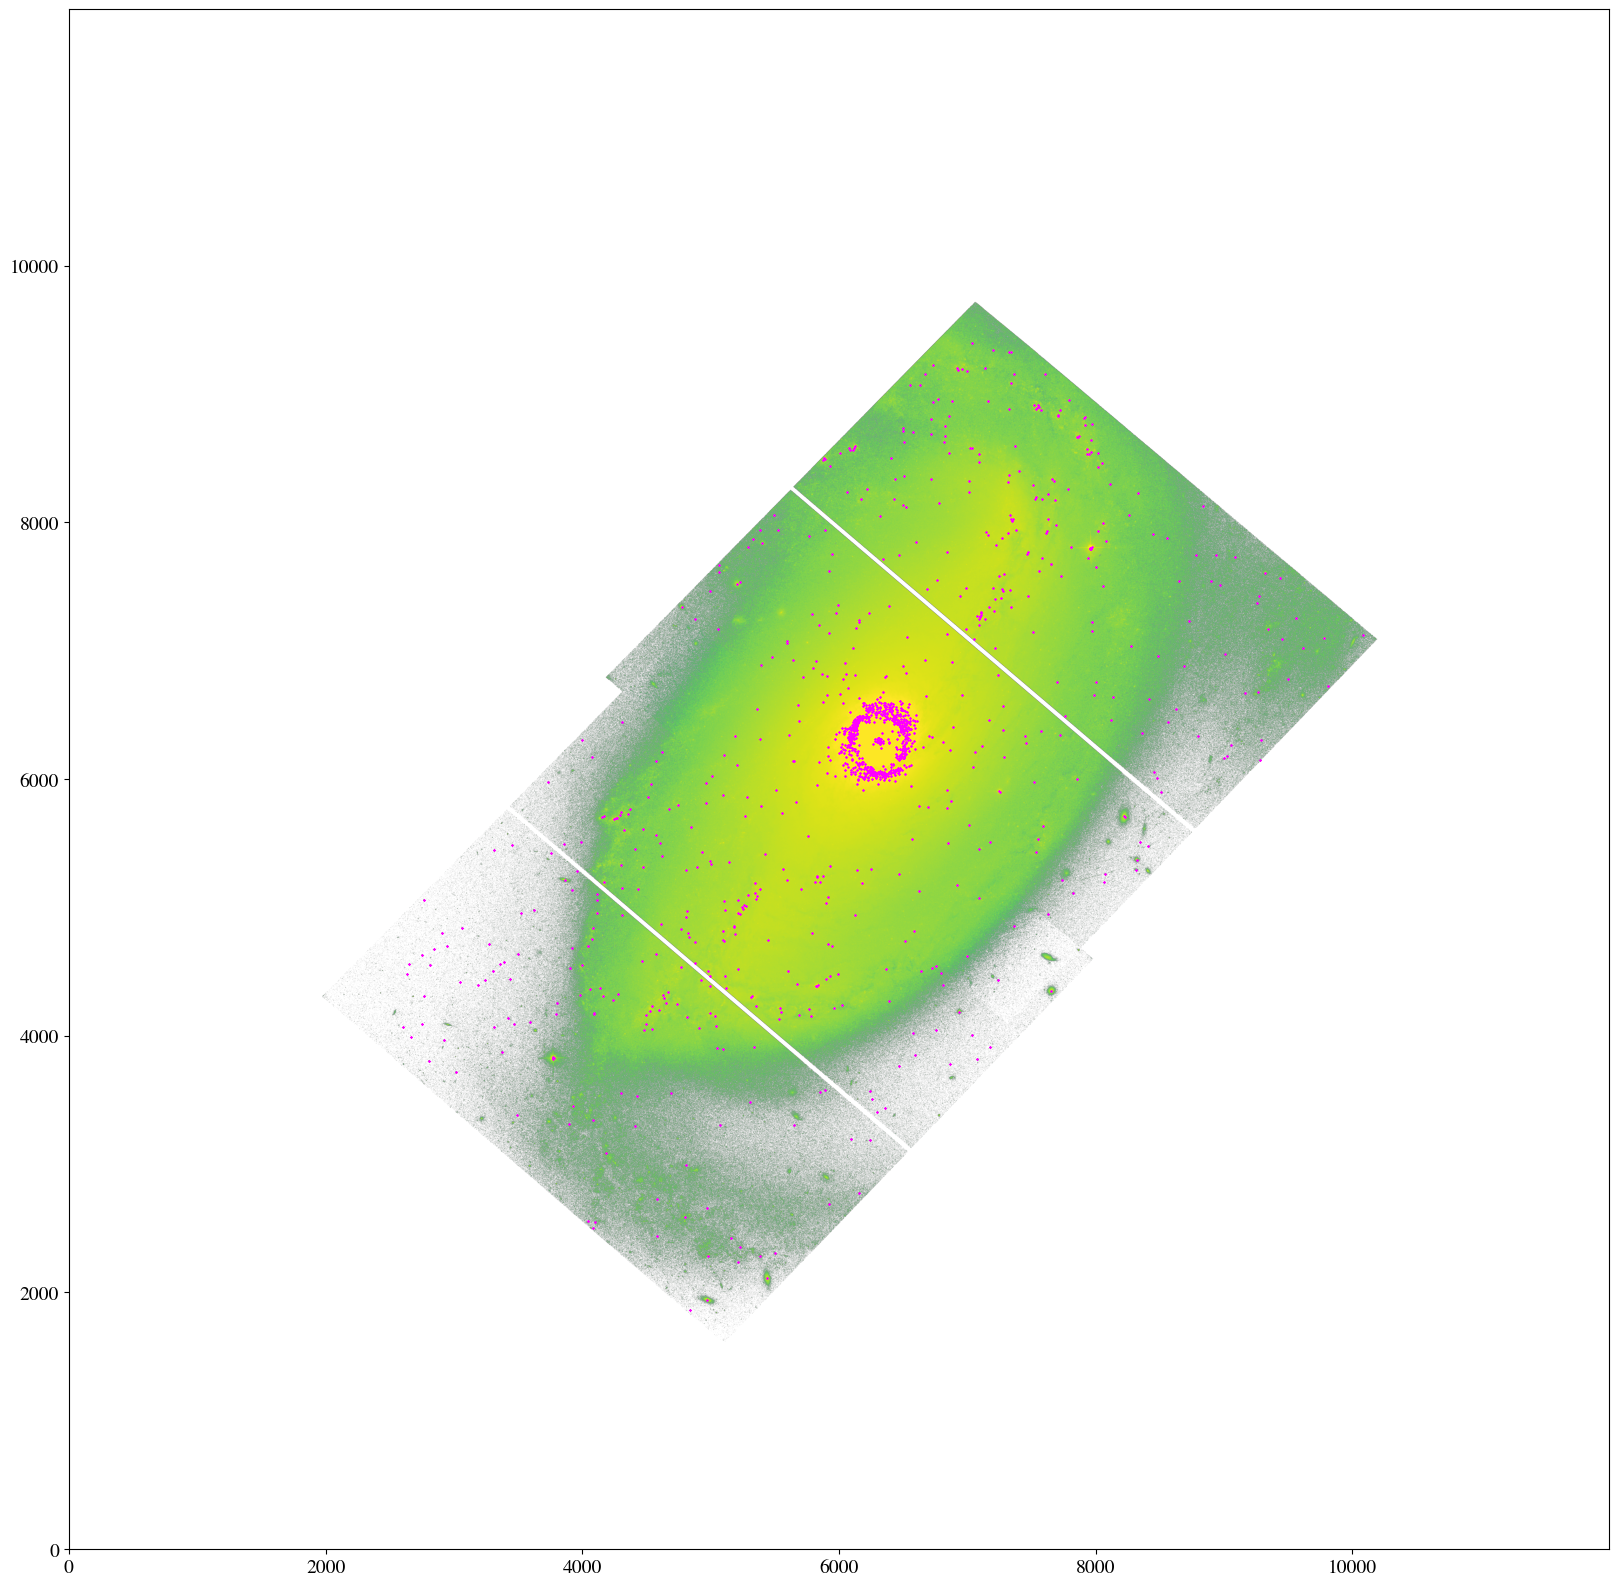

In [13]:
%matplotlib inline
plt.figure(figsize=(20,20))
plt.imshow(np.log10(img), origin = 'lower', vmax = 1.5e-3)
plt.scatter(catalog['xcenter'], catalog['ycenter'], color='magenta', marker='x', s=1)
plt.show()